In [1]:
import gc
import xarray as xr
import numpy as np
from shapely.geometry import Point, LineString, MultiLineString
from shapely.ops import polygonize
from pyproj import CRS, Transformer
import pandas as pd
import geopandas as gpd
from scipy import interpolate

#### CRSs ####
WGS84 = CRS('epsg:4326')  # WGS84
ETRS89UTM = CRS('epsg:25834') # ETRS89 / UTM zone 34N

In [2]:
# %%
# create grid (as polygons) for calculating density rasters
#
def create_grid(xmin,xmax,ymin,ymax,res=0.1,x1=None,x2=None,y1=None,y2=None,save=False):
    print('creating a grid with the resolution of {} metres'.format(res))
    
    # coordinates for the grid to be made
    x = np.arange(xmin, xmax+res, res)
    y = np.arange(ymin, ymax+res, res)
    print("making array with the coordinates")
    
    # taking only the extent set by x1,x2,y1,y2
    if x1 is not None:
        x = x[x>x1]
    if x2 is not None:
        x = x[x<x2]
    if y1 is not None:
        y = y[y>y1]
    if y2 is not None:
        y = y[y<y2]
    # get grid dimensions X,Y
    X = len(x)
    Y = len(y)
    # create horisontal and vertical lines
    hlines = [((x_a, yi), (x_b, yi)) for x_a, x_b in zip(x[:-1], x[1:]) for yi in y]
    vlines = [((xi, y_a), (xi, y_b)) for y_a, y_b in zip(y[:-1], y[1:]) for xi in x]
    print("Creating lines")
    
    # construct grid using the lines
    grids = list(polygonize(MultiLineString(hlines + vlines)))
    grid = gpd.GeoDataFrame(grids,columns=['geometry'])
    print("construct grid using the lines")
    
    #grid.set_geometry('geometry',drop=True,inplace=True)
    grid.crs = ETRS89UTM
    # set id for each grid point
    grid['gridid'] = grid.index+1
    # set the grid point centre coordinates
    x_c = x[:-1]+res/2
    y_c = y[:-1]+res/2
    x_cs, y_cs = np.meshgrid(x_c,y_c)
    x_cs, y_cs = np.meshgrid(np.round(x_c),np.round(y_c)) #number of decimals
    print("set the grid point centre coordinates")
    if save:
        grid['c_x'] = x_cs.T.flatten()
        grid['c_y'] = y_cs.T.flatten()
    else:
        grid['c_coords'] = list(zip(x_cs.T.flatten(),y_cs.T.flatten()))
        grid['c_coords'] = grid['c_coords'].apply(Point)

    return grid

In [3]:
# %%
# saving grid created with create_grid()
#
def save_grid(grid,fname):
    ext = fname.split('.')[-1]
    if ext == 'shp':
        driver = 'ESRI Shapefile'
    elif ext == 'gpkg':
        driver = 'GPKG'
    else:
        logging.error('file format {} not supported')
        return False

    try:
        grid.to_file(filename=fname, driver=driver)
    except:
        return False
    return True

In [4]:
# %%
# load grid for calculating density rasters
#
def load_grid(fname,x1=None,x2=None,y1=None,y2=None):
    # load file
    grid = gpd.read_file(fname)
    # take only the extent set with lon1,lon2,lat1,lat2
    if x1 is not None:
        bounds = grid.geometry.bounds
        rows = bounds.minx>x1
        grid = grid[rows]
    if x2 is not None:
        bounds = grid.geometry.bounds
        rows = bounds.maxx<x2
        grid = grid[rows]
    if y1 is not None:
        bounds = grid.geometry.bounds
        rows = bounds.miny>y1
        grid = grid[rows]
    if y2 is not None:
        bounds = grid.geometry.bounds
        rows = bounds.maxy<y2
        grid = grid[rows]
    # transform grid centre coordinates into Point
    grid['c_coords'] = list(zip(grid['c_x'],grid['c_y']))
    grid['c_coords'] = grid['c_coords'].apply(Point)
    # and drop the original columns
    grid.drop(columns=['c_x','c_y'],inplace=True)
    # rearrange columns and return grid
    return grid[['c_coords','gridid','geometry']]

In [5]:
transformer_lonlatTo2dxy = Transformer.from_crs(WGS84, ETRS89UTM, always_xy=True)
xmin, ymin = transformer_lonlatTo2dxy.transform(17.05540, 59.81651)
xmax, ymax = transformer_lonlatTo2dxy.transform(22.33311, 63.44978)

res1 = 2000
grid1 = create_grid(xmin,xmax,ymin,ymax,res=res1,x1=None,x2=None,y1=None,y2=None,save=False)
save_grid(grid1,'/projappl/project_2018610/data/grids/test_grid_{}m.gpkg'.format(res1))

# res2 = 50000
# grid2 = create_grid(xmin,xmax,ymin,ymax,res=res2,x1=None,x2=None,y1=None,y2=None,save=False)
# save_grid(grid2,'/projappl/project_2018610/data/grids/test_grid_{}m.gpkg'.format(res2))

creating a grid with the resolution of 2000 metres
making array with the coordinates
Creating lines
construct grid using the lines
set the grid point centre coordinates


True

In [10]:
grid1

,geometry,gridid,c_coords
0,"POLYGON ((279848.567 6637561.125, 278848.567 6...",1,POINT (279349 6638061)
1,"POLYGON ((279848.567 6638561.125, 278848.567 6...",2,POINT (279349 6639061)
2,"POLYGON ((279848.567 6639561.125, 278848.567 6...",3,POINT (279349 6640061)
3,"POLYGON ((279848.567 6640561.125, 278848.567 6...",4,POINT (279349 6641061)
4,"POLYGON ((279848.567 6641561.125, 278848.567 6...",5,POINT (279349 6642061)
...,...,...,...
114907,"POLYGON ((566848.567 7031561.125, 565848.567 7...",114908,POINT (566349 7032061)
114908,"POLYGON ((566848.567 7032561.125, 565848.567 7...",114909,POINT (566349 7033061)
114909,"POLYGON ((566848.567 7033561.125, 565848.567 7...",114910,POINT (566349 7034061)
114910,"POLYGON ((566848.567 7034561.125, 565848.567 7...",114911,POINT (566349 7035061)


(6637561.125183143, 7036395.8789351145)

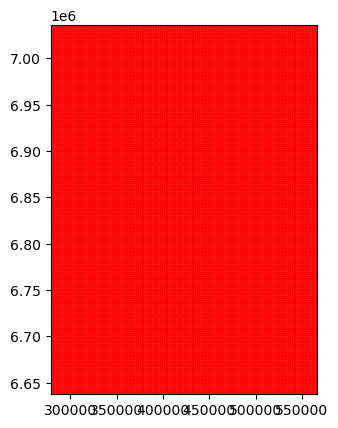

In [7]:
import matplotlib.pyplot as plt
fig,ax = plt.subplots(1,1)
grid1.plot(facecolor='none',edgecolor='r',ax=ax)
#grid2.plot(facecolor='none',linestyle=':',ax=ax)
ax.set_xlim(xmin,xmax)
ax.set_ylim(ymin,ymax)